# <center> Cross validation </center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import random
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

So far in this class, we have studied 
- 2 models for regression: linear regression and KNN
- 3 models for classification: logistic regression, linear discriminant analysis and KNN

A question naturally arises: given a regression or classification task, which of these models to choose? 

Similarly, for a given model, how to tune the hyperparameters (think $K$ in the KNN algorithm) ?

This lecture introduce a procedure that allow to select the "best" algorithm for a problem at hand, based on **resampling methods**. Additionally, we discuss the pitfall of model selection.

## 1- Assessing Model Accuracy

The process of evaluating a model's performance is known as **model assessment**, whereas the process of selecting the proper level of flexibility for a model is known as **model selection**.

### 1-1 On the importance to separate the dataset into training set and testing set

We consider that some response $y$ follows some sinusoidal model:

$$y=f(x)+\epsilon$$

where $f()=\sin()$ and $\epsilon$ follows a uniform distribution in $[-b, b]$

We generate some data $(x_i,y_i)$ using this model.

In [2]:
#real model
def true_function(x):
    f_x = np.sin(x)
    return f_x

#generate noisy data
b=0.4
def gen_data(x):
    y = true_function(x) + np.random.uniform(-b, b, len(x))
    return y

In [3]:
#generate noisy data
np.random.seed(5)
n_train=50
x_train = np.sort(4*np.random.rand(n_train))
y_train = gen_data(x_train)

In [4]:
print(x_train[:10])

[0.00656869 0.00885685 0.09173237 0.09722625 0.32296508 0.5766572
 0.63323947 0.66245144 0.75088491 0.75365862]


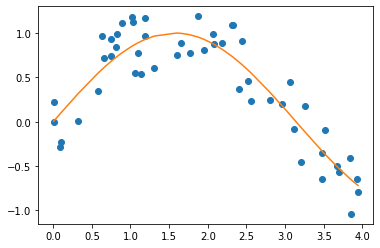

In [5]:
plt.plot(x_train, y_train, 'o', x_train, true_function(x_train), '-')

Let use assume that we only observe the pairs of ponts $(x_i,y_i)$ and that we want to carry on a **polynomial regression** over them:

$$\hat{f}(x)=b_0+b_1x+b_2x^2+\cdot+b_px^p $$

Questions: how to choose $p$?

In [6]:
n_test=10
def average_test_error(M,p):
    scores=np.zeros(M)
    for m in range(M):
        #generate test set
        x_test = np.sort(np.random.rand(n_test))
        y_test = gen_data(x_test)
        scores[m]=np.mean((p(x_test)-y_test)**2)
    return scores 

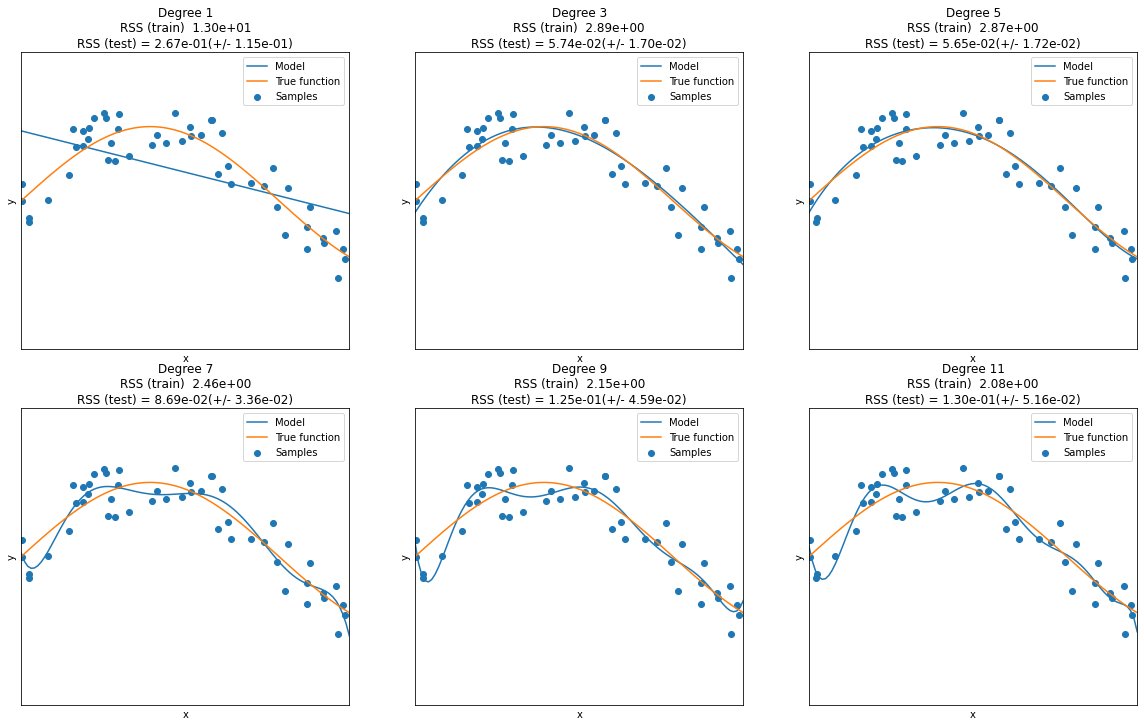

In [7]:
np.random.seed(5)

p_order = [1, 3, 5, 7, 9,11]

plt.figure(figsize=(20, 12))
for i in range(len(p_order)):
    ax = plt.subplot(2, len(p_order)/2, i + 1)
    plt.setp(ax, xticks=(), yticks=())
    p = np.poly1d(np.polyfit(x_train, y_train, p_order[i]))
    RSS = np.sum((y_train - p(x_train))**2)
    scores=average_test_error(100,p)
    X_plot = np.linspace(0, 4, 100)
    plt.plot(X_plot, p(X_plot), label="Model")
    plt.plot(X_plot, true_function(X_plot), label="True function")
    plt.scatter(x_train, y_train, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 4))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nRSS (train)  {:.2e}\nRSS (test) = {:.2e}(+/- {:.2e})".format(
         p_order[i], RSS, scores.mean(), scores.std()))

When we vary the degree of the polynomial, the complexity of the model increases. 

We can study the performances by plotting the estimates of the quadratic errors on a training base on the one hand and on a test base on the other hand. Here, we can imagine to have as many test bases as we want, and we can therefore correctly estimate the squared error of test.

/home/cauwet/.local/lib/python3.6/site-packages/ipykernel_launcher.py:26: RuntimeWarning: divide by zero encountered in log
/home/cauwet/.local/lib/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in log


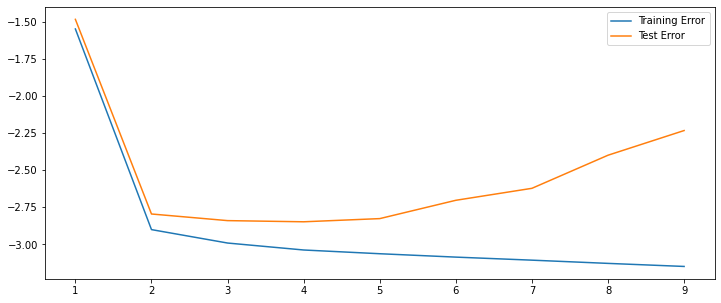

In [8]:
# Plotting the model performance as a function of the polynomial degree p
plt.figure(figsize=(12, 5))

M = 200 

# maximum order of the polynomial to test
max_order = 10
sc_test = np.zeros((max_order))
sc_training = np.zeros((max_order))

for m in range(M):
    x_train = np.sort(4*np.random.rand(n_train))#generate training set
    y_train = gen_data(x_train)
    x_test =np.sort(4*np.random.rand(n_test))#generate test set
    y_test = gen_data(x_test) 

    for p_order in range(1, max_order):
        p=np.poly1d(np.polyfit(x_train, y_train, p_order))#fitting the model on the training data
        sc_training[p_order] += np.mean(
            (p(x_train) - y_train)**2)  # calcul RSS training
        sc_test[p_order] += np.mean(
            (p(x_test) - y_test)**2)  # calcul RSS test      

sc_training = sc_training / M
sc_test = sc_test / M
plt.plot(np.log(sc_training), label="Training Error")
plt.plot(np.log(sc_test), label="Test Error")
plt.legend()

For a too low degree, the approximation is poor, there is *biased*. When we increase the degree of the polynomial, the approximation can be better, but the approximation also tends to take into account the irregularities introduced by an observation noise. The model is then **too** faithful to the training data and deviates from the true model. Consequently, when we try to generalize, i.e. to use the model on new data, the test error will deteriorate (*variance*). 

Remarks: it is possible to plot some similar graphs in the case of classification, looking at the accuracy over the test set and the train set.

<center><img src="lampe.jpg" width="200"></center>  

<center> Always mesure the performance of the model (using MSE, accuracy, error rate, sensitivity, etc ...) on a test set. </center>

### 1-2 The bias-variance trade-off

The U-shape observed on the Performance-Flexibility curves is completely typical and is the result of two antagonistic properties of learning methods: bias and variance.

The trade-off bias-variance is a fundamental concept of machine learning. In this section, we present this concept first conceptually, second on an example and third mathematically. We present this concept in a regression framework, but keep in mind that it exists as well in a classification setting.

#### Conceptual Definition 

**Framework.**

Given some sampled data $(y_i,x_i)$ where $y_i$ is the response and $x_i$ the predictor, building a machine learning model consists into assuming that there exist an unknown function $f$ such that :

$$ 
y_i=f(x_i)+\epsilon_i
$$

Where $\epsilon_i$ is some *noise* over which we can do some assumptions (for example $\mathbb{E}(\epsilon_i)=0$, or $\epsilon_i$ follows a standardized Gaussian distribution).

The goal is to efficiently estimate the function $f$ and filter out the noise. Both bias and variance can be addressed as the source of errors in our machine learning model.

The following definition are taken form [Scott Fortmann-Roe](http://scott.fortmann-roe.com/docs/BiasVariance.html).

**Error due to Bias:**  The error due to bias is taken as the difference between the expected (or average) prediction of our model and the correct value which we are trying to predict. Of course you only have one model so talking about expected or average prediction values might seem a little strange. However, imagine you could repeat the whole model building process more than once: each time you gather new data and run a new analysis creating a new model. Due to randomness in the underlying data sets, the resulting models will have a range of predictions. Bias measures how far off in general these models' predictions are from the correct value.

**Error due to Variance:** The error due to variance is taken as the variability of a model prediction for a given data point. Again, imagine you can repeat the entire model building process multiple times. The variance is how much the predictions for a given point vary between different realizations of the model.

We can create a graphical visualization of bias and variance using a bulls-eye diagram. Imagine that the center of the target is a model that perfectly predicts the correct values. Imagine we can repeat our entire model building process to get a number of separate hits on the target. Each hit represents an individual realization of our model, given the chance variability in the training data we gather. Sometimes we will get a good distribution of training data so we predict very well and we are close to the bulls-eye, while sometimes our training data might be full of outliers or non-standard values resulting in poorer predictions. These different realizations result in a scatter of hits on the target.

We can plot four different cases representing combinations of both high and low bias and variance.
<br>

<center><img src="biasvariance.png" width="400"></center>

#### Visualizing it with an example in python

Obviously, it would be optimal to select a model with the smallest possible bias and variance simultaneously. 

As a matter a fact, the more flexible/complex the model, the more the variance increases and the
bias decreases. As the complexity of the model increases, the bias tends to decrease faster than the variance increases. The average error then decreases. Then, after a certain degree of flexibility, the bias is reduced and the mean error decreases. Then, after a certain degree of flexibility, the bias is reduced and the increase in variance prevails.

The following part, provided by [Aqeel Anwar](https://towardsdatascience.com/understanding-the-bias-variance-tradeoff-and-visualizing-it-with-example-and-python-code-7af2681a10a7), illustrate this claim.

Let us consider the same example as before.

In [9]:
#generate noisy data
x_orig = np.arange(0, 4* np.pi, .2)
y_orig= gen_data(x_orig)

In [10]:
#resampling from the data in order to build the model
def get_rand_data(x, y):
    m = len(x)
    m_new = int(np.round(0.7*m))
    ind = random.sample(range(m), m_new)
    ind = np.sort(ind)
    x1 = x[ind]
    y1 = y[ind]
    return x1, y1

In [11]:
#adjusting a polynomial function of degree p on the data
p_order = [1, 3, 5, 7, 9, 11]
#computing bias and variance from num_data number of resampling
num_data = 2000

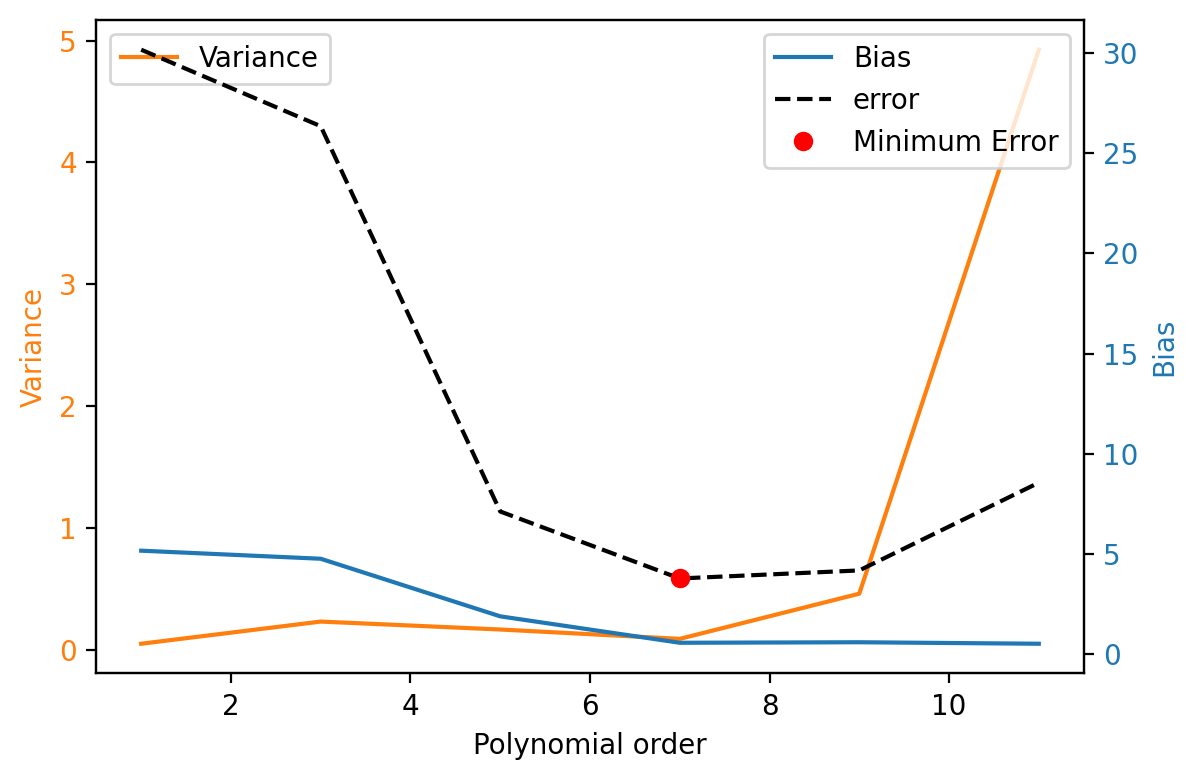

In [12]:
t = np.arange(0.1, 4*np.pi, .2)#test set for estimating bias and variance
P=[]
bb=[]
vv=[]
for i, p_val in enumerate(p_order):
    exp_f_x = np.zeros(len(t))
    var = np.zeros(len(t))
    for j in range(num_data):
        x, y = get_rand_data(x_orig, y_orig)
        p = np.poly1d(np.polyfit(x, y, p_val))
        P.append(p)
        exp_f_x = exp_f_x + p(t)
    exp_f_x = exp_f_x/num_data
    bias = np.linalg.norm(exp_f_x-true_function(t))
    bb.append(bias)
    for j in range(num_data):
        p_t = P.pop(0)
        var = var + np.square(p_t(t)-exp_f_x)
    var = var/num_data
    variance = np.linalg.norm(var)
    vv.append(variance)
    
fig, ax1 = plt.subplots(dpi=200)

color = 'tab:orange'
ax1.set_xlabel('Polynomial order')
ax1.set_ylabel('Variance', color=color)
ax1.plot(p_order, vv, color=color, label = 'Variance')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('Bias', color=color)
ax2.plot(p_order, bb, color=color,  label = 'Bias')
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
sigma=1/12*(2*b)**2
error = np.square(bb)+vv+sigma*len(t)#formula for error rate
min_ind = np.argmin(error)
plt.plot(p_order, error, 'k--', label = 'error')
plt.plot(p_order[min_ind], error[min_ind], 'ro', label= 'Minimum Error')
leg = ax2.legend(loc='upper right')
leg = ax1.legend(loc='upper left')
plt.show()    

Remark: the error is the sum of the squared bias, the variance and some constant term. Pay attention to the scale (right (in blue) and left (in orange) y-axis are scaled differently).

It can be seen that the polynomial of degree $7$ gives us the best fit for our sine curve in the presence of noise. The selection of this polynomial is dependent upon

- The amount and nature of the noise in the samples data
- The amount of training data

Remark: 
- if dataset sampled is not noisy ($\epsilon=0$). Running the same experimentation for this clean dataset will show that the higher the degree of the polynomial the better is the approximation. This is compliant with the Taylor series expansion of the sine curve.
- in real application, it is not possible to compute bias and variance ($f$ is unkown).

In this particular example, the complexity of the model is its polynomial degree. In the case of KNN, the complexity of the model is related to the value of $k$: high value of $k$ leads to high bias and low variance.

#### Theory: bias-variance decomposition of the  error

Good performance therefore requires both low variance and low bias. The measurement of the quality of the model is not only used to quantify its performance, but also of course to find the best sets of parameters that will allow us to optimize the performance of the model.

Let us look at the bias-variance decomposition of the mean squared error (recall: the mean square error is a measure of the quality of the model for regression.)

We assume that the sampled data stem from some model:

$$y=f(x)+\epsilon $$

with $f$ unknown and $\epsilon$ a noise of expectation $0$ and variance $\sigma^2$


The **mean square error** of the model is:

$$\mathbb{E}\left[ (y - \hat{f}(x))^2 \right]$$

Hence, 

\begin{align}
\mathbb{E}\left[(y - \hat{f}(x))^2\right]
 & =\mathbb{E}\left[(f(x)+\epsilon  - \hat{f}(x) )^2\right] \\
 & = \mathbb{E}\left[(f(x)+\epsilon  - \hat{f}(x) +\mathbb{E}[\hat{f}(x)]-\mathbb{E}[\hat{f}(x)])^2\right] \\
 & = \mathbb{E}\left[(f(x)-\mathbb{E}[\hat{f}(x)])^2\right]+\mathbb{E}[\epsilon^2]+\mathbb{E}\left[(\mathbb{E}[\hat{f}(x)]- \hat{f}(x))^2\right] 
+2\mathbb{E}\left[(f(x)-\mathbb{E}[\hat{f}(x)])\epsilon\right]
+2\mathbb{E}\left[\epsilon(\mathbb{E}[\hat{f}(x)]- \hat{f}(x))\right]
+2\mathbb{E}\left[(\mathbb{E}[\hat{f}(x)]- \hat{f}(x))(f(x)-\mathbb{E}[\hat{f}(x)])\right]\\
& = (f(x)-\mathbb{E}[\hat{f}(x)])^2+\mathbb{E}[\epsilon^2]+\mathbb{E}\left[(\mathbb{E}[\hat{f}(x)]- \hat{f}(x))^2\right] 
+2(f(x)-\mathbb{E}[\hat{f}(x)])\mathbb{E}[\epsilon]
+2\mathbb{E}[\epsilon]\mathbb{E}\left[\mathbb{E}[\hat{f}(x)]- \hat{f}(x)\right]
+2\mathbb{E}\left[\mathbb{E}[\hat{f}(x)]- \hat{f}(x)\right](f(x)-\mathbb{E}[\hat{f}(x)])\\
& = (f(x)-\mathbb{E}[\hat{f}(x)])^2+\mathbb{E}[\epsilon^2]+\mathbb{E}\left[(\mathbb{E}[\hat{f}(x)]- \hat{f}(x))^2\right]\\
& = (f(x)-\mathbb{E}[\hat{f}(x)])^2+{Var}[\epsilon]+{Var}\left[\hat{f}(x)\right]\\
& = {Bias}[\hat{f}(x)]^2+{Var}[\epsilon]+{Var}\left[\hat{f}(x)\right]\\
& = {Bias}[\hat{f}(x)]^2+\sigma^2+{Var}\left[\hat{f}(x)\right].
\end{align}

A close-form of the bias and variance depends on the model at hand. It is not always possible to obtain it. In the cas of KNN, a closed-form expression exists that relates the bias-variance decomposition to the parameter $K$.

Remark: the mean square error can never be smaller than the error due to noise ($\sigma^2$).

<u>Example: KNN</u>

$$\hat{f}(x)=\frac{1}{K}\sum_{x_i\in\mathcal{N}(x)} y_i $$

and 

$${Var}\left[\hat{f}(x)\right]=\frac{\sigma^2}{K} $$

$${Bias}[\hat{f}(x)]^2=\left( f(x) - \frac{1}{K}\sum_{x_i\in\mathcal{N}(x)} y_i \right)^2 $$

The bias is a monotone rising function of $K$, while the variance drops off as $K$ is increased.

### 1-3 Overfitting and underfitting

One of the major problems in model design is to find the best model while avoiding overfitting.

As previously seen, a trade-off must be made between bias and variance, or between under/overfitting

- under-fitting : the prediction is too far from the training data, 
- over-fitting: the prediction is too close to the training data. 

**Overfitting is the result of two factors:**

- modeling: the model is too complex (e.g., too non-linear)
- dimensionality: too many parameters to estimate

It is not necessarily possible to avoid overfitting with more data because : 
 
 - the amount of data needed increases with dimensionality (*curse of dimensionality*). The figure below illustrates this problem

<center><img src="Ccurse_dimensionality.png" width="500"></center>

The dimension space increases exponentially when the dimension increased from 1 to 2 to 3, the space accordingly increased from 10 to 100 to 1000.

## 2-Cross validation

In the python code used previously, we already relied on **resampling** methods. We repeatedly drawing samples from a training set and refitting a polynomial on each sample in order to estimate the variability of the model and the test error.

Such an approach may allow us to obtain information that would not be available from fitting the model only once using the original training sample.

We have seen in Section 1 the distinction between the test error rate and the training error rate. The test error is the average error that results from using a statistical learning method to predict the response on a new observation - that is, a measurement that was not used in training the method. Given a data set, the use of a particular statistical learning method is warranted if it results in a low test error. 

Unfortunately, we do not often have at hand a designed test set. In contrast, the training error can be easily calculated by applying the statistical learning method to the observations used in its training. But as
we saw in Section 1, the training error rate often is quite different from the test error rate, and in particular the former can dramatically underestimate the latter.


### 2-1 Validation set approach

Suppose that we would like to estimate the test error associated with fitting a particular machine learning method on a set of observations. The **validation set approach** consists into randomly dividing the available set of observations into two parts:
- a training set
- a validation set or hold-out set. 

The model is fit on the training set, and the fitted model is used to predict the responses for the observations in the validation set. The resulting validation set error rate - typically assessed using MSE in the case of a quantitative response - provides an estimate of the test error rate.

<center><img src="cv19.png" width="600"></center>

In [13]:
data=pd.read_csv('insurance.csv')
data_smoker=data[data['smoker']=='yes']
df=data_smoker[data_smoker['bmi']<30].copy()

In [14]:
df.shape

(129, 7)

In [29]:
# create training and testing vars
#test with random_state=42
X_train, X_test, y_train, y_test = train_test_split(df[['age','bmi']], df['charges'], test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(103, 2)
(26, 2)


In [30]:
# fit a model
lm = linear_model.LinearRegression()
model = lm.fit(X_train, y_train)
predictions = lm.predict(X_test)

Text(0, 0.5, 'Predictions')

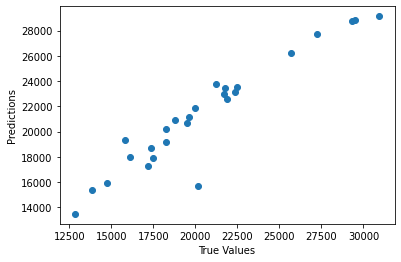

In [31]:
## The line / model
plt.scatter(y_test, predictions)
plt.xlabel("True Values")
plt.ylabel("Predictions")

In [32]:
#get the MSE
from sklearn.metrics import mean_squared_error
print(mean_squared_error(predictions, y_test))

2956897.0862603155


The validation set approach is conceptually simple and is easy to implement. But it has two potential drawbacks:
- Re-run the previous code and look how the score varies depending on the split between training set and testing set. The validation estimate of the test error rate can be highly variable, depending on precisely which observations are included in the training set and which observations are included in the validation set.
- In the validation approach, only a subset of the observations - those that are included in the training set rather than in the validation set - are used to fit the model. Since machine learning methods tend to perform worse when trained on fewer observations, this suggests that the validation set error rate may tend to overestimate the test error rate for the model fit on the entire data set.

### 2-2 Leave-one-out cross validation

Leave-one-out cross-validation (LOOCV) is closely related to the validation set approac, but it attempts to address that method's drawbacks.

Like the validation set approach, LOOCV involves splitting the set of observations into two parts. However, instead of creating two subsets of comparable size, a single observation is used for the validation set, and the remaining observations make up the training set. The LOOCV procedure can be described as follow:

For $i\in\{1,\cdots,n\}$ do
- Train the model on $\{(x_1,y_1),\cdots,(x_{i-1},y_{i-1}),(x_{i+1},y_{i+1}),\cdots,(x_{n},y_{n})\}$
- Test the model on $(x_i,y_i)$
- Get the corresponding measure of performance $MSE_i$

EndFor

The LOOCV estimate for the test MSE is the average of these $n$ test error estimates:

 $$\frac{1}{n}\sum_{i=1}^n MSE_i $$
 
 
<center><img src="cv2.png" width="600"></center>
 
LOOCV has a couple of major advantages over the validation set approach:

- it has far less bias. In LOOCV, we repeatedly fit the machine learning method using training sets that contain $n-1$ observations, almost as many as are in the entire data set. This is in contrast to the validation set approach, in which the training set is typically around half the size of the original data set. Consequently, the LOOCV approach tends not to overestimate the test error rate as much as the validation set approach does. 

- in contrast to the validation approach which will yield different results when applied repeatedly due to randomness in the training/validation set splits, performing LOOCV multiple times will always yield the same results: there is no randomness in the training/validation set splits.

In [33]:
#define cross-validation method to use
cv = LeaveOneOut()

#build multiple linear regression model
model = LinearRegression()

#use LOOCV to evaluate model
scores = cross_val_score(model, df[['age','bmi']], df['charges'],scoring='neg_mean_squared_error',cv=cv)

#view RMSE
print(-scores.mean())

12093137.284564814


LOOCV has the potential to be expensive to implement, since the model has to be fit $n$ times. This can be very time consuming if $n$ is large and if each individual model is slow to fit.

Remark: a LOOCV is a very general method, and can be used with any kind of predictive modeling. For example we could use it with logistic regression or linear discriminant analysis.

### 2-3 k fold cross validation

An alternative to LOOCV is $k$-fold CV. This approach involves randomly dividing the set of observations into $k$ groups, or folds, of approximately equal size. The first fold is treated as a validation set, and the method
is fit on the remaining $k-1$ folds. The mean squared error, $MSE_1$, is then computed on the observations in the held-out fold. This procedure is repeated $k$ times; each time, a different group of observations is treated
as a validation set. This process results in $k$ estimates of the test error, $MSE_1$, $MSE_2$, . . . , $MSE_k$. The k-fold CV estimate is computed by averaging these values.
<br>
<center><img src="cv3.png" width="600"></center>

Some statistical learning methods have computationally intensive fitting procedures, and so performing LOOCV may pose computational problems, especially if $n$ is extremely large. In contrast, performing $10$-fold CV requires fitting the learning procedure only ten times, which may be much more feasible.

In [20]:
cv = KFold(n_splits=10, random_state=3, shuffle=True)
#use LOOCV to evaluate model
scores = cross_val_score(model, df[['age','bmi']], df['charges'],scoring='neg_mean_squared_error',cv=cv)

#view RMSE
print(-scores.mean())

12084339.031473521


<center><img src="test.jpg"></center>

- Go to [quizizz.com/join](https://quizizz.com/join)
- Enter code 2804 0478